In [25]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# ==============================================================================
# STYLE
# ==============================================================================
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ==============================================================================
# PATHS
# ==============================================================================
BASE_DIR = Path(r"c:\Python\Personal\kfm-ms\codes")

LEVEL1_DIR = BASE_DIR / "pest_level_1"
LEVEL2_DIR = BASE_DIR / "pest_level_2"

TRUTH_PATH = LEVEL1_DIR / "master_run" / "master_truth.csv"

FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_FIG = FIG_DIR / "truth_level1_level2_well_comparison.svg"

TOKEN_REGEX = re.compile(r"_r:(\d+)_c:(\d+)_sp:(\d+)")


# ==============================================================================
# HELPERS
# ==============================================================================
def find_latest_par_file(run_dir: Path) -> Path:
    par_files = sorted(run_dir.glob("*inversion_level_*.par.csv"))
    if not par_files:
        par_files = sorted((run_dir / "master_run").glob("*inversion_level_*.par.csv"))
    if not par_files:
        raise FileNotFoundError(f"No parameter CSV files found in {run_dir}")
    return par_files[-1]


def load_grid_template(run_dir: Path) -> pd.DataFrame:
    grid_path = run_dir / "org" / "grid_candidates.csv"
    if not grid_path.exists():
        raise FileNotFoundError(f"Missing org grid file: {grid_path}")
    return pd.read_csv(grid_path)


def load_posterior_mean(par_file: Path) -> pd.Series:
    df_pars = pd.read_csv(par_file, index_col=0)
    posterior_df = df_pars.drop(index="base", errors="ignore")
    if posterior_df.empty:
        raise ValueError(f"No ensemble rows available in {par_file} after removing 'base'.")
    return posterior_df.mean(axis=0)


def make_truth_schedule(truth_df: pd.DataFrame) -> pd.DataFrame:
    required = {"well_id", "r", "c", "sp", "q"}
    missing = required - set(truth_df.columns)
    if missing:
        raise KeyError(f"Truth file missing columns: {missing}")
    return truth_df[["well_id", "r", "c", "sp", "q"]].copy().sort_values(
        ["well_id", "sp", "r", "c"]
    ).reset_index(drop=True)


def make_effective_schedule(par_series: pd.Series, grid_template: pd.DataFrame, truth_df: pd.DataFrame) -> pd.DataFrame:
    well_map = (
        truth_df[["r", "c", "well_id"]]
        .drop_duplicates()
        .set_index(["r", "c"])["well_id"]
        .to_dict()
    )

    qref_lookup = {
        (int(r), int(c), int(sp)): float(qref)
        for r, c, sp, qref in grid_template[["r", "c", "sp", "qref"]].itertuples(index=False, name=None)
    }

    records = []
    for col_name, multiplier in par_series.items():
        m = TOKEN_REGEX.search(str(col_name))
        if not m:
            continue

        r = int(m.group(1))
        c = int(m.group(2))
        sp = int(m.group(3))

        qref = qref_lookup.get((r, c, sp), None)
        if qref is None:
            continue

        well_id = well_map.get((r, c), -1)
        q_eff = float(qref) * float(multiplier)

        records.append({
            "well_id": well_id,
            "r": r,
            "c": c,
            "sp": sp,
            "qref": float(qref),
            "multiplier": float(multiplier),
            "q_effective": q_eff,
        })

    out = pd.DataFrame(records)
    if out.empty:
        raise ValueError("No parsable pumping values found.")
    return out.sort_values(["well_id", "sp", "r", "c"]).reset_index(drop=True)


# ==============================================================================
# MAIN
# ==============================================================================
def main():
    print(f"[INFO] Reading truth from: {TRUTH_PATH}")
    truth_df = pd.read_csv(TRUTH_PATH)

    par_file_l1 = find_latest_par_file(LEVEL1_DIR)
    par_file_l2 = find_latest_par_file(LEVEL2_DIR)

    grid_l1 = load_grid_template(LEVEL1_DIR)
    grid_l2 = load_grid_template(LEVEL2_DIR)

    print(f"[INFO] Level 1 par file: {par_file_l1}")
    print(f"[INFO] Level 2 par file: {par_file_l2}")

    truth_sched = make_truth_schedule(truth_df)
    l1_post_series = load_posterior_mean(par_file_l1)
    l2_post_series = load_posterior_mean(par_file_l2)

    l1_sched = make_effective_schedule(l1_post_series, grid_l1, truth_df)
    l2_sched = make_effective_schedule(l2_post_series, grid_l2, truth_df)

    wells = (
        truth_sched[["well_id", "r", "c"]]
        .drop_duplicates()
        .sort_values(["well_id"])
        .reset_index(drop=True)
    )

    n_wells = len(wells)
    ncols = 4
    nrows = (n_wells + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(8.5, 11),
        sharex=True,
        sharey=False
    )
    axes = axes.flatten()

    # Small x-offsets to help distinguish overlapping points
    x_offsets = {
        "Truth": -0.08,
        "Level 1": 0.0,
        "Level 2": 0.08,
    }

    for i, (_, row) in enumerate(wells.iterrows()):
        ax = axes[i]
        well_id = int(row["well_id"])
        r = int(row["r"])
        c = int(row["c"])

        truth_well = truth_sched[truth_sched["well_id"] == well_id].copy()
        l1_well = l1_sched[l1_sched["well_id"] == well_id].copy()
        l2_well = l2_sched[l2_sched["well_id"] == well_id].copy()

        if truth_well.empty or l1_well.empty or l2_well.empty:
            ax.set_axis_off()
            continue

        truth_s = truth_well.set_index("sp")["q"].sort_index()
        l1_s = l1_well.set_index("sp")["q_effective"].sort_index()
        l2_s = l2_well.set_index("sp")["q_effective"].sort_index()

        # Scatter only, no lines
        ax.scatter(
            truth_s.index + x_offsets["Truth"], truth_s.values,
            color="black", s=6, marker="o",
            edgecolors="black", linewidths=0.4,
            label="Truth", zorder=4
        )
        ax.scatter(
            l1_s.index + x_offsets["Level 1"], l1_s.values,
            facecolors="white", edgecolors="#1f77b4", s=18, marker="s",
            linewidths=0.9, label="Level 1", zorder=3
        )
        ax.scatter(
            l2_s.index + x_offsets["Level 2"], l2_s.values,
            color="#d62728", s=14, marker="^",
            edgecolors="#d62728", linewidths=0.5,
            label="Level 2", zorder=3
        )

        ax.set_title(f"Well {well_id} (r={r}, c={c})", pad=3)
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.tick_params(axis="both", direction="out", length=3, width=0.6)

        if i % ncols == 0:
            ax.set_ylabel("Pumping Rate ($m^3/d$)")
        if i >= (nrows - 1) * ncols:
            ax.set_xlabel("Stress Period (Weeks)")

    # Turn off unused axes
    for j in range(n_wells, len(axes)):
        axes[j].set_axis_off()

    # Compact figure-level legend at bottom
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.012),
        handletextpad=0.5,
        columnspacing=1.6
    )

    fig.tight_layout(rect=[0.03, 0.04, 0.98, 0.98])

    fig.savefig(OUT_FIG)
    plt.close(fig)

    print(f"[OK] Saved figure to: {OUT_FIG}")


if __name__ == "__main__":
    main()

[INFO] Reading truth from: c:\Python\Personal\kfm-ms\codes\pest_level_1\master_run\master_truth.csv


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Python\\Personal\\kfm-ms\\codes\\pest_level_1\\master_run\\master_truth.csv'

In [5]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# ==============================================================================
# STYLE
# ==============================================================================
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ==============================================================================
# PATHS
# ==============================================================================
BASE_DIR = Path(r"c:\Python\Personal\kfm-ms\codes")

LEVEL1_DIR = BASE_DIR / "pest_level_1"
LEVEL2_DIR = BASE_DIR / "pest_level_2"

TRUTH_PATH = LEVEL1_DIR / "master_run" / "master_truth.csv"

FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_FIG = FIG_DIR / "truth_level1_level2_well_comparison.svg"

TOKEN_REGEX = re.compile(r"_r:(\d+)_c:(\d+)_sp:(\d+)")


# ==============================================================================
# HELPERS
# ==============================================================================
def find_latest_par_file(run_dir: Path) -> Path:
    par_files = sorted(run_dir.glob("*inversion_level_*.par.csv"))
    if not par_files:
        par_files = sorted((run_dir / "master_run").glob("*inversion_level_*.par.csv"))
    if not par_files:
        raise FileNotFoundError(f"No parameter CSV files found in {run_dir}")
    return par_files[-1]


def load_grid_template(run_dir: Path) -> pd.DataFrame:
    grid_path = run_dir / "org" / "grid_candidates.csv"
    if not grid_path.exists():
        raise FileNotFoundError(f"Missing org grid file: {grid_path}")
    return pd.read_csv(grid_path)


def load_posterior_summary(par_file: Path) -> pd.DataFrame:
    """
    Return a DataFrame indexed by parameter name with columns:
    p05, mean, p95
    """
    df_pars = pd.read_csv(par_file, index_col=0)
    posterior_df = df_pars.drop(index="base", errors="ignore")

    if posterior_df.empty:
        raise ValueError(f"No ensemble rows available in {par_file} after removing 'base'.")

    summary = pd.DataFrame({
        "p05": posterior_df.quantile(0.05, axis=0),
        "mean": posterior_df.mean(axis=0),
        "p95": posterior_df.quantile(0.95, axis=0),
    })
    return summary


def make_truth_schedule(truth_df: pd.DataFrame) -> pd.DataFrame:
    required = {"well_id", "r", "c", "sp", "q"}
    missing = required - set(truth_df.columns)
    if missing:
        raise KeyError(f"Truth file missing columns: {missing}")
    return truth_df[["well_id", "r", "c", "sp", "q"]].copy().sort_values(
        ["well_id", "sp", "r", "c"]
    ).reset_index(drop=True)


def make_effective_schedule(par_summary: pd.DataFrame, grid_template: pd.DataFrame, truth_df: pd.DataFrame) -> pd.DataFrame:
    well_map = (
        truth_df[["r", "c", "well_id"]]
        .drop_duplicates()
        .set_index(["r", "c"])["well_id"]
        .to_dict()
    )

    qref_lookup = {
        (int(r), int(c), int(sp)): float(qref)
        for r, c, sp, qref in grid_template[["r", "c", "sp", "qref"]].itertuples(index=False, name=None)
    }

    records = []
    for col_name, stats in par_summary.iterrows():
        m = TOKEN_REGEX.search(str(col_name))
        if not m:
            continue

        r = int(m.group(1))
        c = int(m.group(2))
        sp = int(m.group(3))

        qref = qref_lookup.get((r, c, sp), None)
        if qref is None:
            continue

        well_id = well_map.get((r, c), -1)

        records.append({
            "well_id": well_id,
            "r": r,
            "c": c,
            "sp": sp,
            "qref": float(qref),
            "p05": float(qref) * float(stats["p05"]),
            "mean": float(qref) * float(stats["mean"]),
            "p95": float(qref) * float(stats["p95"]),
        })

    out = pd.DataFrame(records)
    if out.empty:
        raise ValueError("No parsable pumping values found.")
    return out.sort_values(["well_id", "sp", "r", "c"]).reset_index(drop=True)


# ==============================================================================
# MAIN
# ==============================================================================
def main():
    print(f"[INFO] Reading truth from: {TRUTH_PATH}")
    truth_df = pd.read_csv(TRUTH_PATH)

    par_file_l1 = find_latest_par_file(LEVEL1_DIR)
    par_file_l2 = find_latest_par_file(LEVEL2_DIR)

    grid_l1 = load_grid_template(LEVEL1_DIR)
    grid_l2 = load_grid_template(LEVEL2_DIR)

    print(f"[INFO] Level 1 par file: {par_file_l1}")
    print(f"[INFO] Level 2 par file: {par_file_l2}")

    truth_sched = make_truth_schedule(truth_df)
    l1_post_summary = load_posterior_summary(par_file_l1)
    l2_post_summary = load_posterior_summary(par_file_l2)

    l1_sched = make_effective_schedule(l1_post_summary, grid_l1, truth_df)
    l2_sched = make_effective_schedule(l2_post_summary, grid_l2, truth_df)

    wells = (
        truth_sched[["well_id", "r", "c"]]
        .drop_duplicates()
        .sort_values(["well_id"])
        .reset_index(drop=True)
    )

    n_wells = len(wells)
    ncols = 4
    nrows = (n_wells + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(8.5, 11),
        sharex=True,
        sharey=False
    )
    axes = axes.flatten()

    # Small x-offsets to help distinguish overlapping points
    x_offsets = {
        "Truth": -0.08,
        "Level 1": 0.0,
        "Level 2": 0.08,
    }

    for i, (_, row) in enumerate(wells.iterrows()):
        ax = axes[i]
        well_id = int(row["well_id"])
        r = int(row["r"])
        c = int(row["c"])

        truth_well = truth_sched[truth_sched["well_id"] == well_id].copy()
        l1_well = l1_sched[l1_sched["well_id"] == well_id].copy()
        l2_well = l2_sched[l2_sched["well_id"] == well_id].copy()

        if truth_well.empty or l1_well.empty or l2_well.empty:
            ax.set_axis_off()
            continue

        truth_s = truth_well.set_index("sp")["q"].sort_index()
        l1_s = l1_well.set_index("sp").sort_index()
        l2_s = l2_well.set_index("sp").sort_index()

        # Truth
        ax.scatter(
            truth_s.index + x_offsets["Truth"], truth_s.values,
            color="black", s=12, marker="o",
            edgecolors="black", linewidths=0.4,
            label="Truth", zorder=4
        )

        # Level 1 uncertainty band + mean
        ax.fill_between(
            l1_s.index.values + x_offsets["Level 1"],
            l1_s["p05"].values,
            l1_s["p95"].values,
            color="#1f77b4",
            alpha=0.18,
            linewidth=0,
            zorder=1
        )
        ax.scatter(
            l1_s.index.values + x_offsets["Level 1"],
            l1_s["mean"].values,
            facecolors="white", edgecolors="#1f77b4", s=18, marker="s",
            linewidths=0.9, label="Level 1 mean", zorder=3
        )

        # Level 2 uncertainty band + mean
        ax.fill_between(
            l2_s.index.values + x_offsets["Level 2"],
            l2_s["p05"].values,
            l2_s["p95"].values,
            color="#d62728",
            alpha=0.18,
            linewidth=0,
            zorder=1
        )
        ax.scatter(
            l2_s.index.values + x_offsets["Level 2"],
            l2_s["mean"].values,
            color="#d62728", s=14, marker="^",
            edgecolors="#d62728", linewidths=0.5,
            label="Level 2 mean", zorder=3
        )

        ax.set_title(f"Well {well_id} (r={r}, c={c})", pad=3)
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.tick_params(axis="both", direction="out", length=3, width=0.6)

        if i % ncols == 0:
            ax.set_ylabel("Pumping Rate ($m^3/d$)")
        if i >= (nrows - 1) * ncols:
            ax.set_xlabel("Stress Period (Weeks)")

    # Turn off unused axes
    for j in range(n_wells, len(axes)):
        axes[j].set_axis_off()

    # Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.012),
        handletextpad=0.5,
        columnspacing=1.6
    )

    fig.tight_layout(rect=[0.03, 0.04, 0.98, 0.98])

    fig.savefig(OUT_FIG)
    plt.close(fig)

    print(f"[OK] Saved figure to: {OUT_FIG}")


if __name__ == "__main__":
    main()

[INFO] Reading truth from: c:\Python\Personal\kfm-ms\codes\pest_level_1\master_run\master_truth.csv


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Python\\Personal\\kfm-ms\\codes\\pest_level_1\\master_run\\master_truth.csv'

## noptmax = 0 run

In [6]:
from operator import le
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from pathlib import Path
import pyemu
import matplotlib.patches as patches

# ==============================================================================
# DATA PATH CONFIGURATION
# ==============================================================================
PEST_DIR = r"C:\Python\Personal\kfm-ms\codes\pest_noptmax0"
MASTER_DIR = os.path.join(PEST_DIR, "master_run")
TARGET_OBS_PATH = os.path.join(PEST_DIR, "dummy_obs.csv")
MASTER_TRUTH_PATH = os.path.join(PEST_DIR, "master_truth.csv")
PST_CONTROL_PATH = os.path.join(PEST_DIR, "inversion_level_1.pst")

# Mapping labeled targets to custom professional presentation strings
files_to_compare = {
    "PEST Predictions": "inversion_level_1.obs_data.csv",
}

if not all(os.path.exists(p) for p in [TARGET_OBS_PATH, MASTER_TRUTH_PATH, PST_CONTROL_PATH]):
    raise FileNotFoundError(f"[-] Missing critical baseline or control files inside: {PEST_DIR}")

# 1. Load active PEST control weights and strip prefixes
print("[+] Extracting active observation channels from control file...")
pst = pyemu.Pst(PST_CONTROL_PATH)
active_obs = pst.observation_data[pst.observation_data["weight"] > 0.0].copy()

active_obs.index = active_obs.index.str.lower()
clean_active_names = [idx.split(":")[-1] if ":" in idx else idx for idx in active_obs.index]
active_obs_names = set(clean_active_names)

# 2. Load baseline targets and master grid truth
df_target = pd.read_csv(TARGET_OBS_PATH)
df_target["obsnme"] = df_target["obsnme"].astype(str).str.lower()
df_target = df_target.rename(columns={"obsval": "obsval_target"})

# Keep ONLY rows where the observation was actively weighted by PEST
df_target = df_target[df_target["obsnme"].isin(active_obs_names)].reset_index(drop=True)

df_truth = pd.read_csv(MASTER_TRUTH_PATH)
df_grid_map = df_truth.sort_values(by=['r', 'c', 'sp']).drop_duplicates(subset=['r', 'c']).reset_index(drop=True)

# Initialize master spatial dataframe tracking coordinates over time
df_spatial = df_target[["obsnme", "obsval_target"]].copy()

# Extract compliance point IDs using the updated absolute head text filter token 'hd_p'
df_spatial['point_num'] = df_spatial['obsnme'].str.extract(r'_cp(\d+)').fillna(0).astype(int)

# Map row and column matrix indexes cleanly out of df_spatial tracking column
max_grid_nodes = len(df_grid_map)
df_spatial['r'] = df_spatial['point_num'].apply(lambda x: df_grid_map['r'].iloc[x % max_grid_nodes])
df_spatial['c'] = df_spatial['point_num'].apply(lambda x: df_grid_map['c'].iloc[x % max_grid_nodes])

spatial_columns = []

# 3. Parse the vertical structure of the obs_data summary file directly
for label, filename in files_to_compare.items():
    file_path = os.path.join(MASTER_DIR, filename)
    if not os.path.exists(file_path):
        print(f"[!] Warning: Missing {filename}. Skipping from layout.")
        continue
        
    df_obs_data = pd.read_csv(file_path)
    df_obs_data.columns = df_obs_data.columns.str.lower()
    
    # Clean the PstFrom prefixes from the observation name column
    df_obs_data["obsnme"] = df_obs_data["obsnme"].apply(lambda x: x.split(":")[-1].lower() if ":" in x else x.lower())
    
    # Isolate columns and rename to map predictions cleanly
    df_slice = df_obs_data[["obsnme", "obsval"]].rename(columns={"obsval": f"sim_base_{label}"})
    df_slice = df_slice[df_slice["obsnme"].isin(active_obs_names)]
    
    # Merge cleanly into tracking master coordinates dataframe
    df_spatial = pd.merge(df_spatial, df_slice, on="obsnme", how="left")
    spatial_columns.append((label, f"sim_base_{label}"))

# ==============================================================================
# GRAPHICS PANEL GENERATION (OPTIMIZED FOR 8.5x11 REPORT BLOCKS)
# ==============================================================================
size = 13 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']

# Compact figure dimensions suited for stacking inside portrait page columns
fig, ax = plt.subplots(1, 1, figsize=(11, 4.5))

sim_cols = [col for _, col in spatial_columns if col in df_spatial.columns]
df_filtered = df_spatial.copy()

all_vals = [df_filtered["obsval_target"].values] + [df_filtered[c].values for c in sim_cols]
min_val = min(np.min(v) for v in all_vals if len(v) > 0)
max_val = max(np.max(v) for v in all_vals if len(v) > 0)

# Build linear bin boundaries mirroring the physical gradient scale limits
bins = np.linspace(min_val - 2.0, max_val + 2.0, 50)

target_data = df_filtered["obsval_target"].values

# ==============================================================================
# RENDER DISTRIBUTION FIELDS WITH EXPLICIT STYLE MATCHING
# ==============================================================================
# Reference Model: Solid translucent blue fill (alpha=0.5)
ax.hist(target_data, bins=bins, color='#0072B2', alpha=0.5, edgecolor='none', zorder=1)
ax.hist(target_data, bins=bins, histtype='step', color='#0072B2', lw=2.2, zorder=2)

# PEST Predictions: Pure outline step profile (no fill)
for label, col in spatial_columns:
    if col in df_filtered.columns:
        sim_data = df_filtered[col].values
        ax.hist(sim_data, bins=bins, histtype='step', color='#E69F00', lw=2.2, zorder=3)

# Grid and typography framing
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=size-2)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

ax.set_xlabel("Absolute Head (m)", fontsize=size)
ax.set_ylabel("Frequency (Nodes)", fontsize=size)
ax.grid(True, which="both", linestyle=":", alpha=0.25, zorder=1)

# ==============================================================================
# FIXED: FORCE EXPLICIT LEGEND STYLES (MATCHES CANVAS 1:1)
# ==============================================================================
legend_elements = [
    # Reference Model: Shows a solid translucent blue patch (alpha=0.5) matching the bars
    patches.Patch(facecolor='#0072B2', alpha=0.5, edgecolor='none', 
                  label=f'Reference Model (Mean: {target_data.mean():.1f} m)'),
    
    # PEST Predictions: Shows an empty box with a thick orange border matching the step line
    patches.Patch(facecolor='none', edgecolor='#E69F00', linewidth=2.2, 
                  label=f'PEST Predictions (Mean: {sim_data.mean():.1f} m)')
]

# Render the solid, opaque white legend box over the grid lines
ax.legend(handles=legend_elements, loc='upper center', framealpha=1.0, 
          facecolor='white', edgecolor='#cccccc', fontsize=size-2)

plt.tight_layout()
output_filename = os.path.join(PEST_DIR, "Report_Format_Absolute_Head_Histogram.svg")
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"[+] Clean report plot successfully saved to -> {output_filename}")

plt.show()

FileNotFoundError: [-] Missing critical baseline or control files inside: C:\Python\Personal\kfm-ms\codes\pest_noptmax0

[INFO] Reading truth from: c:\python\Personal\kfm-ms\codes\master_run_level_1\master_truth.csv
[INFO] Successfully loaded base run from: c:\python\Personal\kfm-ms\codes\master_run_level_1\inversion_level_1.2.base.par
[INFO] Successfully loaded base run from: c:\python\Personal\kfm-ms\codes\master_run_level_2\inversion_level_2.2.base.par

RMSE SUMMARY
Level 1 RMSE:  692.0998
Level 1 NRMSE:  1.0090 (normalized by mean truth = 685.9062)
Level 2 RMSE:  1059.7013
Level 2 NRMSE:  1.5450 (normalized by mean truth = 685.9062)
[OK] Saved RMSE summary to: c:\python\Personal\kfm-ms\codes\figures\truth_schedule_rmse_summary.csv


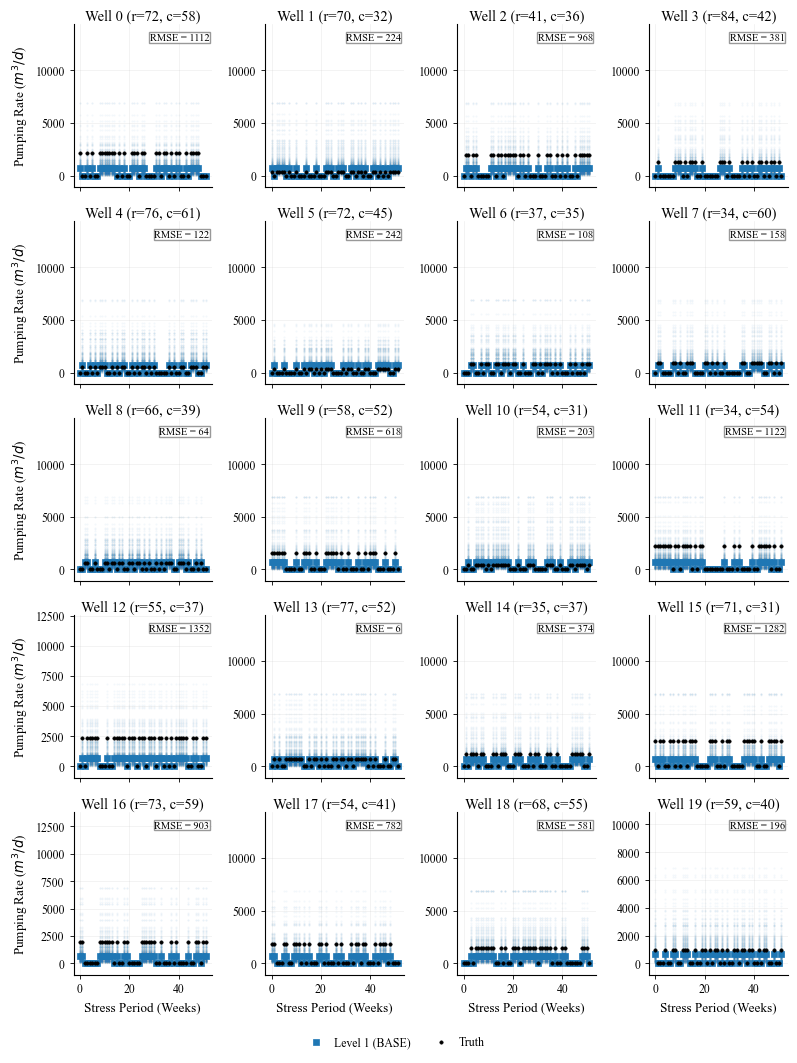

[OK] Saved Level 1 plot to: c:\python\Personal\kfm-ms\codes\figures\truth_level1_well_comparison.svg


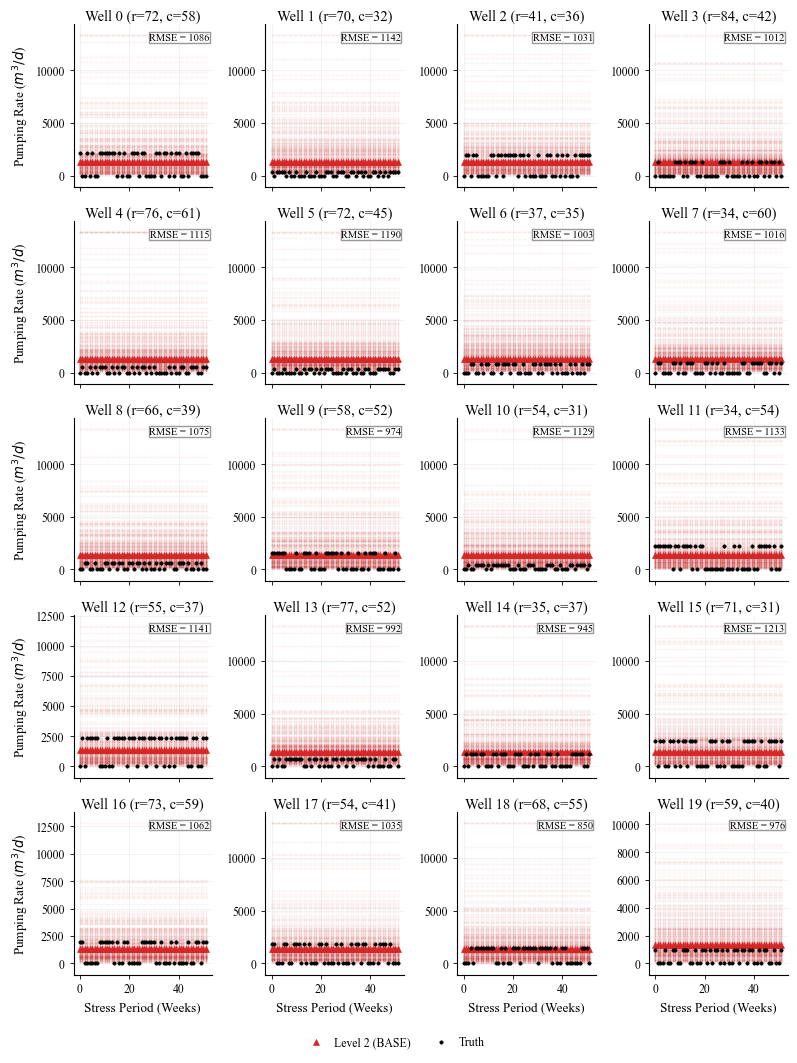

[OK] Saved Level 2 plot to: c:\python\Personal\kfm-ms\codes\figures\truth_level2_well_comparison.svg


In [30]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

# ==============================================================================
# STYLE
# ==============================================================================
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ==============================================================================
# PATHS
# ==============================================================================
BASE_DIR = Path(r"c:\python\Personal\kfm-ms\codes")

LEVEL1_DIR = BASE_DIR / "pest_level_1"
LEVEL2_DIR = BASE_DIR / "pest_level_2"

MASTER_RUN_L1_DIR = BASE_DIR / "master_run_level_1"
MASTER_RUN_L2_DIR = BASE_DIR / "master_run_level_2"

TRUTH_PATH = MASTER_RUN_L1_DIR / "master_truth.csv"

FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Separate output figures
OUT_FIG_L1 = FIG_DIR / "truth_level1_well_comparison.svg"
OUT_FIG_L2 = FIG_DIR / "truth_level2_well_comparison.svg"

# RMSE summary output
OUT_RMSE_CSV = FIG_DIR / "truth_schedule_rmse_summary.csv"

TOKEN_REGEX = re.compile(r"_r:(\d+)_c:(\d+)_sp:(\d+)")

# ==============================================================================
# HELPERS
# ==============================================================================
def find_latest_par_file(run_dir: Path, master_run_dir: Path) -> Path:
    par_files = sorted(run_dir.glob("*inversion_level_*.par.csv"))
    if not par_files:
        par_files = sorted(master_run_dir.glob("*inversion_level_*.par.csv"))
    if not par_files:
        raise FileNotFoundError(
            f"No parameter CSV files found in {run_dir} or {master_run_dir}"
        )
    return par_files[-1]


def load_grid_template(run_dir: Path) -> pd.DataFrame:
    grid_path = run_dir / "org" / "grid_candidates.csv"
    if not grid_path.exists():
        grid_path = run_dir / "grid_candidates.csv"
    if not grid_path.exists():
        raise FileNotFoundError(f"Missing grid file in {run_dir}")
    return pd.read_csv(grid_path)


def load_realizations_and_base(par_file: Path) -> tuple[pd.DataFrame, pd.Series]:
    """
    Loads all realizations from the CSV file and explicitly reads the
    accompanying PEST space-delimited '.base.par' file, checking both
    the active directory and the 'master_run' subdirectory.
    """
    df_pars = pd.read_csv(par_file, index_col=0)
    realizations_df = df_pars.drop(index="base", errors="ignore")

    base_file_name = par_file.name.replace(".par.csv", ".base.par")

    possible_paths = [
        par_file.parent / base_file_name,
        par_file.parent / "master_run" / base_file_name,
        MASTER_RUN_L1_DIR / base_file_name,
        MASTER_RUN_L1_DIR / "master_run" / base_file_name,
        MASTER_RUN_L2_DIR / base_file_name,
        MASTER_RUN_L2_DIR / "master_run" / base_file_name,
    ]

    base_file_path = None
    for path in possible_paths:
        if path.exists():
            base_file_path = path
            break

    if base_file_path is not None:
        df_base_raw = pd.read_csv(
            base_file_path,
            sep=r"\s+",
            skiprows=1,
            names=["parnme", "parval", "scale", "offset"]
        )
        base_series = df_base_raw.set_index("parnme")["parval"]
        print(f"[INFO] Successfully loaded base run from: {base_file_path}")
    else:
        print(f"[WARNING] Could not find '{base_file_name}' in any standard directories.")
        print(f"          Checked: {[str(p) for p in possible_paths]}")
        print("          Defaulting to first ensemble row.")
        base_series = df_pars.iloc[0]
        realizations_df = df_pars.iloc[1:]

    return realizations_df, base_series


def make_truth_schedule(truth_df: pd.DataFrame) -> pd.DataFrame:
    required = {"well_id", "r", "c", "sp", "q"}
    missing = required - set(truth_df.columns)
    if missing:
        raise KeyError(f"Truth file missing columns: {missing}")
    return truth_df[["well_id", "r", "c", "sp", "q"]].copy().sort_values(
        ["well_id", "sp", "r", "c"]
    ).reset_index(drop=True)


def make_effective_schedule_multi(
    par_data: pd.DataFrame | pd.Series,
    grid_template: pd.DataFrame,
    truth_df: pd.DataFrame
) -> pd.DataFrame:
    """Handles both single row (Series) and multiple rows (DataFrame) for multipliers."""
    well_map = (
        truth_df[["r", "c", "well_id"]]
        .drop_duplicates()
        .set_index(["r", "c"])["well_id"]
        .to_dict()
    )

    qref_lookup = {
        (int(r), int(c), int(sp)): float(qref)
        for r, c, sp, qref in grid_template[["r", "c", "sp", "qref"]].itertuples(index=False, name=None)
    }

    if isinstance(par_data, pd.Series):
        df_m = pd.DataFrame([par_data])
    else:
        df_m = par_data

    records = []
    for col_name in df_m.columns:
        m = TOKEN_REGEX.search(str(col_name))
        if not m:
            continue

        r = int(m.group(1))
        c = int(m.group(2))
        sp = int(m.group(3))

        qref = qref_lookup.get((r, c, sp), None)
        if qref is None:
            continue

        well_id = well_map.get((r, c), -1)
        multipliers = df_m[col_name].values

        for idx, mult in enumerate(multipliers):
            realization_id = "base" if isinstance(par_data, pd.Series) else df_m.index[idx]
            records.append({
                "realization": realization_id,
                "well_id": well_id,
                "r": r,
                "c": c,
                "sp": sp,
                "q_effective": float(qref) * float(mult),
            })

    out = pd.DataFrame(records)
    if out.empty:
        raise ValueError("No parsable pumping values found.")
    return out.sort_values(["realization", "well_id", "sp", "r", "c"]).reset_index(drop=True)


def calculate_global_y_limits(truth_sched, l1_base, l1_real, l2_base, l2_real) -> dict:
    """Calculates shared Y-limits per well across both levels for fair comparison."""
    all_data = pd.concat([
        truth_sched.rename(columns={"q": "val"})[["well_id", "val"]],
        l1_base.rename(columns={"q_effective": "val"})[["well_id", "val"]],
        l1_real.rename(columns={"q_effective": "val"})[["well_id", "val"]],
        l2_base.rename(columns={"q_effective": "val"})[["well_id", "val"]],
        l2_real.rename(columns={"q_effective": "val"})[["well_id", "val"]]
    ])

    limits = {}
    for well_id, group in all_data.groupby("well_id"):
        ymin = group["val"].min()
        ymax = group["val"].max()
        padding = (ymax - ymin) * 0.08 if ymax != ymin else 1.0
        limits[well_id] = (ymin - padding, ymax + padding)
    return limits


def compute_rmse_metrics(base_sched: pd.DataFrame, truth_sched: pd.DataFrame) -> dict:
    merged = truth_sched[["well_id", "sp", "q"]].merge(
        base_sched[["well_id", "sp", "q_effective"]],
        on=["well_id", "sp"],
        how="inner"
    )

    if merged.empty:
        raise ValueError("No overlapping truth/base schedule entries found for RMSE calculation.")

    diff = merged["q_effective"] - merged["q"]
    rmse = float(np.sqrt(np.mean(diff**2)))

    truth_mean = float(merged["q"].mean())
    nrmse = rmse / truth_mean if truth_mean != 0 else np.nan

    return {
        "rmse": rmse,
        "truth_mean": truth_mean,
        "nrmse": nrmse,
        "n_points": int(len(merged)),
    }


def compute_well_rmse(base_sched: pd.DataFrame, truth_sched: pd.DataFrame, well_id: int) -> float:
    merged = truth_sched[truth_sched["well_id"] == well_id][["well_id", "sp", "q"]].merge(
        base_sched[base_sched["well_id"] == well_id][["well_id", "sp", "q_effective"]],
        on=["well_id", "sp"],
        how="inner"
    )

    if merged.empty:
        return np.nan

    diff = merged["q_effective"] - merged["q"]
    return float(np.sqrt(np.mean(diff**2)))


# ==============================================================================
# PLOTTING ENGINE
# ==============================================================================
def plot_level_comparison(level_label, base_color, base_marker, base_sched, real_sched, truth_sched, wells, y_limits, out_path):
    n_wells = len(wells)
    ncols = 4
    nrows = (n_wells + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=(8.5, 11), sharex=True, sharey=False
    )
    axes = axes.flatten()

    for i, (_, row) in enumerate(wells.iterrows()):
        ax = axes[i]
        well_id = int(row["well_id"])
        r = int(row["r"])
        c = int(row["c"])

        t_w = truth_sched[truth_sched["well_id"] == well_id].sort_values("sp")
        b_w = base_sched[base_sched["well_id"] == well_id].sort_values("sp")
        r_w = real_sched[real_sched["well_id"] == well_id]

        if t_w.empty or b_w.empty:
            ax.set_axis_off()
            continue

        # Faint realizations (drawn behind)
        for _, group in r_w.groupby("realization"):
            sorted_group = group.sort_values("sp")
            ax.scatter(
                sorted_group["sp"], sorted_group["q_effective"],
                color=base_color, alpha=0.05, s=2, marker="o", linewidths=0, zorder=2
            )

        # Dark BASE run
        ax.scatter(
            b_w["sp"], b_w["q_effective"],
            color=base_color, s=18, marker=base_marker,
            edgecolors=base_color, linewidths=0.5,
            label=f"{level_label} (BASE)", zorder=4
        )

        # Truth
        ax.scatter(
            t_w["sp"], t_w["q"],
            color="black", s=6, marker="o",
            edgecolors="black", linewidths=0.4,
            label="Truth", zorder=5
        )

        # Per-well error annotation (BASE vs Truth), no decimals
        well_rmse = compute_well_rmse(base_sched, truth_sched, well_id)
        if np.isfinite(well_rmse):
            ax.text(
                0.98, 0.95,
                f"RMSE = {int(round(well_rmse))}",
                transform=ax.transAxes,
                va="top",
                ha="right",
                fontsize=7.5,
                bbox=dict(facecolor="white", edgecolor="gray", alpha=0.80, pad=0.2)
            )

        if well_id in y_limits:
            ax.set_ylim(y_limits[well_id])

        # No log scaling
        ax.set_title(f"Well {well_id} (r={r}, c={c})", pad=3)
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.tick_params(axis="both", direction="out", length=3, width=0.6)

        if i % ncols == 0:
            ax.set_ylabel("Pumping Rate ($m^3/d$)")
        if i >= (nrows - 1) * ncols:
            ax.set_xlabel("Stress Period (Weeks)")

    for j in range(n_wells, len(axes)):
        axes[j].set_axis_off()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="lower center", ncol=2, frameon=False,
        bbox_to_anchor=(0.5, 0.012), handletextpad=0.5, columnspacing=1.6
    )

    fig.tight_layout(rect=[0.03, 0.04, 0.98, 0.98])
    fig.savefig(out_path)
    plt.show()

    print(f"[OK] Saved {level_label} plot to: {out_path}")


# ==============================================================================
# MAIN
# ==============================================================================
def main():
    print(f"[INFO] Reading truth from: {TRUTH_PATH}")
    truth_df = pd.read_csv(TRUTH_PATH)

    par_file_l1 = find_latest_par_file(LEVEL1_DIR, MASTER_RUN_L1_DIR)
    par_file_l2 = find_latest_par_file(LEVEL2_DIR, MASTER_RUN_L2_DIR)

    grid_l1 = load_grid_template(LEVEL1_DIR)
    grid_l2 = load_grid_template(LEVEL2_DIR)

    l1_real_df, l1_base_ser = load_realizations_and_base(par_file_l1)
    l2_real_df, l2_base_ser = load_realizations_and_base(par_file_l2)

    truth_sched = make_truth_schedule(truth_df)

    l1_base_sched = make_effective_schedule_multi(l1_base_ser, grid_l1, truth_df)
    l1_real_sched = make_effective_schedule_multi(l1_real_df, grid_l1, truth_df)

    l2_base_sched = make_effective_schedule_multi(l2_base_ser, grid_l2, truth_df)
    l2_real_sched = make_effective_schedule_multi(l2_real_df, grid_l2, truth_df)

    l1_metrics = compute_rmse_metrics(l1_base_sched, truth_sched)
    l2_metrics = compute_rmse_metrics(l2_base_sched, truth_sched)

    metrics_df = pd.DataFrame([
        {
            "level": "Level 1",
            "rmse": l1_metrics["rmse"],
            "truth_mean": l1_metrics["truth_mean"],
            "nrmse": l1_metrics["nrmse"],
            "n_points": l1_metrics["n_points"],
        },
        {
            "level": "Level 2",
            "rmse": l2_metrics["rmse"],
            "truth_mean": l2_metrics["truth_mean"],
            "nrmse": l2_metrics["nrmse"],
            "n_points": l2_metrics["n_points"],
        },
    ])

    metrics_df.to_csv(OUT_RMSE_CSV, index=False)

    print("\nRMSE SUMMARY")
    print(f"Level 1 RMSE:  {l1_metrics['rmse']:.4f}")
    print(f"Level 1 NRMSE:  {l1_metrics['nrmse']:.4f} (normalized by mean truth = {l1_metrics['truth_mean']:.4f})")
    print(f"Level 2 RMSE:  {l2_metrics['rmse']:.4f}")
    print(f"Level 2 NRMSE:  {l2_metrics['nrmse']:.4f} (normalized by mean truth = {l2_metrics['truth_mean']:.4f})")
    print(f"[OK] Saved RMSE summary to: {OUT_RMSE_CSV}")

    wells = (
        truth_sched[["well_id", "r", "c"]]
        .drop_duplicates()
        .sort_values(["well_id"])
        .reset_index(drop=True)
    )

    y_limits = calculate_global_y_limits(
        truth_sched, l1_base_sched, l1_real_sched, l2_base_sched, l2_real_sched
    )

    plot_level_comparison(
        level_label="Level 1",
        base_color="#1f77b4",
        base_marker="s",
        base_sched=l1_base_sched,
        real_sched=l1_real_sched,
        truth_sched=truth_sched,
        wells=wells,
        y_limits=y_limits,
        out_path=OUT_FIG_L1
    )

    plot_level_comparison(
        level_label="Level 2",
        base_color="#d62728",
        base_marker="^",
        base_sched=l2_base_sched,
        real_sched=l2_real_sched,
        truth_sched=truth_sched,
        wells=wells,
        y_limits=y_limits,
        out_path=OUT_FIG_L2
    )


if __name__ == "__main__":
    main()

[INFO] Reading truth from: c:\python\Personal\kfm-ms\codes\master_run_level_1\master_truth.csv
[INFO] Successfully loaded base run from: c:\python\Personal\kfm-ms\codes\master_run_level_1\inversion_level_1.2.base.par
[INFO] Successfully loaded base run from: c:\python\Personal\kfm-ms\codes\master_run_level_2\inversion_level_2.2.base.par

RMSE SUMMARY
Level 1 RMSE:  692.0998
Level 2 RMSE:  1059.7013
[OK] Saved RMSE summary to: c:\python\Personal\kfm-ms\codes\figures\truth_schedule_rmse_summary.csv


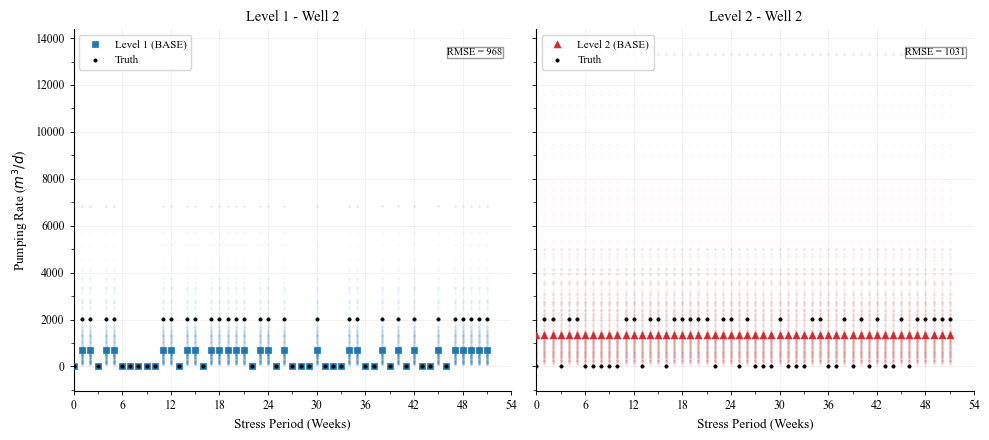

[OK] Saved well 2 comparison to: c:\python\Personal\kfm-ms\codes\figures\truth_well12_level1_vs_level2_all_realizations.svg


In [50]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ==============================================================================
# STYLE
# ==============================================================================
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ==============================================================================
# PATHS
# ==============================================================================
BASE_DIR = Path(r"c:\python\Personal\kfm-ms\codes")

LEVEL1_DIR = BASE_DIR / "pest_level_1"
LEVEL2_DIR = BASE_DIR / "pest_level_2"

MASTER_RUN_L1_DIR = BASE_DIR / "master_run_level_1"
MASTER_RUN_L2_DIR = BASE_DIR / "master_run_level_2"

TRUTH_PATH = MASTER_RUN_L1_DIR / "master_truth.csv"

FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_FIG_WELL0 = FIG_DIR / "truth_well12_level1_vs_level2_all_realizations.svg"
OUT_RMSE_CSV = FIG_DIR / "truth_schedule_rmse_summary.csv"

TOKEN_REGEX = re.compile(r"_r:(\d+)_c:(\d+)_sp:(\d+)")

WELL_ID_TO_PLOT = 2

# ==============================================================================
# HELPERS
# ==============================================================================
def find_latest_par_file(run_dir: Path, master_run_dir: Path) -> Path:
    par_files = sorted(run_dir.glob("*inversion_level_*.par.csv"))
    if not par_files:
        par_files = sorted(master_run_dir.glob("*inversion_level_*.par.csv"))
    if not par_files:
        raise FileNotFoundError(
            f"No parameter CSV files found in {run_dir} or {master_run_dir}"
        )
    return par_files[-1]


def load_grid_template(run_dir: Path) -> pd.DataFrame:
    grid_path = run_dir / "org" / "grid_candidates.csv"
    if not grid_path.exists():
        grid_path = run_dir / "grid_candidates.csv"
    if not grid_path.exists():
        raise FileNotFoundError(f"Missing grid file in {run_dir}")
    return pd.read_csv(grid_path)


def load_realizations_and_base(par_file: Path) -> tuple[pd.DataFrame, pd.Series]:
    df_pars = pd.read_csv(par_file, index_col=0)
    realizations_df = df_pars.drop(index="base", errors="ignore")

    base_file_name = par_file.name.replace(".par.csv", ".base.par")

    possible_paths = [
        par_file.parent / base_file_name,
        par_file.parent / "master_run" / base_file_name,
        MASTER_RUN_L1_DIR / base_file_name,
        MASTER_RUN_L1_DIR / "master_run" / base_file_name,
        MASTER_RUN_L2_DIR / base_file_name,
        MASTER_RUN_L2_DIR / "master_run" / base_file_name,
    ]

    base_file_path = None
    for path in possible_paths:
        if path.exists():
            base_file_path = path
            break

    if base_file_path is not None:
        df_base_raw = pd.read_csv(
            base_file_path,
            sep=r"\s+",
            skiprows=1,
            names=["parnme", "parval", "scale", "offset"]
        )
        base_series = df_base_raw.set_index("parnme")["parval"]
        print(f"[INFO] Successfully loaded base run from: {base_file_path}")
    else:
        print(f"[WARNING] Could not find '{base_file_name}' in any standard directories.")
        print(f"          Checked: {[str(p) for p in possible_paths]}")
        print("          Defaulting to first ensemble row.")
        base_series = df_pars.iloc[0]
        realizations_df = df_pars.iloc[1:]

    return realizations_df, base_series


def make_truth_schedule(truth_df: pd.DataFrame) -> pd.DataFrame:
    required = {"well_id", "r", "c", "sp", "q"}
    missing = required - set(truth_df.columns)
    if missing:
        raise KeyError(f"Truth file missing columns: {missing}")
    return truth_df[["well_id", "r", "c", "sp", "q"]].copy().sort_values(
        ["well_id", "sp", "r", "c"]
    ).reset_index(drop=True)


def make_effective_schedule_multi(
    par_data: pd.DataFrame | pd.Series,
    grid_template: pd.DataFrame,
    truth_df: pd.DataFrame
) -> pd.DataFrame:
    well_map = (
        truth_df[["r", "c", "well_id"]]
        .drop_duplicates()
        .set_index(["r", "c"])["well_id"]
        .to_dict()
    )

    qref_lookup = {
        (int(r), int(c), int(sp)): float(qref)
        for r, c, sp, qref in grid_template[["r", "c", "sp", "qref"]].itertuples(index=False, name=None)
    }

    if isinstance(par_data, pd.Series):
        df_m = pd.DataFrame([par_data])
    else:
        df_m = par_data

    records = []
    for col_name in df_m.columns:
        m = TOKEN_REGEX.search(str(col_name))
        if not m:
            continue

        r = int(m.group(1))
        c = int(m.group(2))
        sp = int(m.group(3))

        qref = qref_lookup.get((r, c, sp), None)
        if qref is None:
            continue

        well_id = well_map.get((r, c), -1)
        multipliers = df_m[col_name].values

        for idx, mult in enumerate(multipliers):
            realization_id = "base" if isinstance(par_data, pd.Series) else df_m.index[idx]
            records.append({
                "realization": realization_id,
                "well_id": well_id,
                "r": r,
                "c": c,
                "sp": sp,
                "q_effective": float(qref) * float(mult),
            })

    out = pd.DataFrame(records)
    if out.empty:
        raise ValueError("No parsable pumping values found.")
    return out.sort_values(["realization", "well_id", "sp", "r", "c"]).reset_index(drop=True)


def compute_rmse_metrics(base_sched: pd.DataFrame, truth_sched: pd.DataFrame) -> dict:
    merged = truth_sched[["well_id", "sp", "q"]].merge(
        base_sched[["well_id", "sp", "q_effective"]],
        on=["well_id", "sp"],
        how="inner"
    )

    if merged.empty:
        raise ValueError("No overlapping truth/base schedule entries found for RMSE calculation.")

    diff = merged["q_effective"] - merged["q"]
    rmse = float(np.sqrt(np.mean(diff**2)))

    truth_mean = float(merged["q"].mean())
    nrmse = rmse / truth_mean if truth_mean != 0 else np.nan

    return {
        "rmse": rmse,
        "truth_mean": truth_mean,
        "nrmse": nrmse,
        "n_points": int(len(merged)),
    }


def compute_well_rmse(base_sched: pd.DataFrame, truth_sched: pd.DataFrame, well_id: int) -> float:
    merged = truth_sched[truth_sched["well_id"] == well_id][["well_id", "sp", "q"]].merge(
        base_sched[base_sched["well_id"] == well_id][["well_id", "sp", "q_effective"]],
        on=["well_id", "sp"],
        how="inner"
    )

    if merged.empty:
        raise ValueError(f"No overlapping truth/base entries found for well {well_id}.")

    diff = merged["q_effective"] - merged["q"]
    return float(np.sqrt(np.mean(diff ** 2)))


def calculate_global_y_limits(truth_sched, l1_real_sched_all, l2_real_sched_all, well_id: int):
    all_vals = []

    t_w = truth_sched[truth_sched["well_id"] == well_id]
    if not t_w.empty:
        all_vals.extend(t_w["q"].tolist())

    for sched in [l1_real_sched_all, l2_real_sched_all]:
        w = sched[sched["well_id"] == well_id]
        if not w.empty:
            all_vals.extend(w["q_effective"].tolist())

    if not all_vals:
        return None

    ymin = min(all_vals)
    ymax = max(all_vals)
    pad = (ymax - ymin) * 0.08 if ymax != ymin else 1.0
    return ymin - pad, ymax + pad


def plot_like_full_axes(ax, y_limits):
    ax.set_xlim(0, 54)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(3))
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))

    if y_limits is not None:
        ax.set_ylim(y_limits)

    ax.tick_params(axis="both", direction="out", length=3, width=0.6)
    ax.tick_params(axis="x", which="minor", length=2, width=0.5)
    ax.tick_params(axis="y", which="minor", length=2, width=0.5)


def plot_well_side_by_side(truth_sched, l1_real_sched_all, l2_real_sched_all, l1_base_sched, l2_base_sched, y_limits, out_path):
    well_id = WELL_ID_TO_PLOT

    t_w = truth_sched[truth_sched["well_id"] == well_id].sort_values("sp")
    l1_w = l1_real_sched_all[l1_real_sched_all["well_id"] == well_id]
    l2_w = l2_real_sched_all[l2_real_sched_all["well_id"] == well_id]

    l1_b = l1_base_sched[l1_base_sched["well_id"] == well_id].sort_values("sp")
    l2_b = l2_base_sched[l2_base_sched["well_id"] == well_id].sort_values("sp")

    if t_w.empty:
        raise ValueError(f"No truth data found for well {well_id}.")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

    panels = [
        ("Level 1", axes[0], l1_w, l1_b, "#1f77b4", "s", l1_base_sched),
        ("Level 2", axes[1], l2_w, l2_b, "#d62728", "^", l2_base_sched),
    ]

    for label, ax, data, base_w, color, marker, base_sched in panels:
        if data.empty:
            ax.set_axis_off()
            continue

        # All realizations as faint points
        for _, group in data.groupby("realization"):
            sorted_group = group.sort_values("sp")
            ax.scatter(
                sorted_group["sp"],
                sorted_group["q_effective"],
                color=color,
                alpha=0.05,
                s=3,
                marker="o",
                linewidths=0,
                zorder=2
            )

        # BASE
        ax.scatter(
            base_w["sp"],
            base_w["q_effective"],
            color=color,
            s=24,
            marker=marker,
            edgecolors=color,
            linewidths=0.5,
            label=f"{label} (BASE)",
            zorder=4
        )

        # Truth
        ax.scatter(
            t_w["sp"],
            t_w["q"],
            color="black",
            s=6,
            marker="o",
            edgecolors="black",
            linewidths=0.4,
            label="Truth",
            zorder=5
        )

        # RMSE label for this well only
        well_rmse = compute_well_rmse(
            l1_base_sched if label == "Level 1" else l2_base_sched,
            truth_sched,
            well_id
        )
        ax.text(
            0.98, 0.95,
            f"RMSE = {int(round(well_rmse))}",
            transform=ax.transAxes,
            va="top",
            ha="right",
            fontsize=7.5,
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.80, pad=0.2)
        )

        plot_like_full_axes(ax, y_limits)

        ax.set_title(f"{label} - Well {well_id}")
        ax.set_xlabel("Stress Period (Weeks)")
        ax.grid(True, alpha=0.2, linewidth=0.5)

    axes[0].set_ylabel("Pumping Rate ($m^3/d$)")
    axes[0].legend(loc="best", fontsize=8)
    axes[1].legend(loc="upper left", fontsize=8)

    fig.tight_layout()
    fig.savefig(out_path)
    plt.show()

    print(f"[OK] Saved well {well_id} comparison to: {out_path}")


# ==============================================================================
# MAIN
# ==============================================================================
def main():
    print(f"[INFO] Reading truth from: {TRUTH_PATH}")
    truth_df = pd.read_csv(TRUTH_PATH)

    par_file_l1 = find_latest_par_file(LEVEL1_DIR, MASTER_RUN_L1_DIR)
    par_file_l2 = find_latest_par_file(LEVEL2_DIR, MASTER_RUN_L2_DIR)

    grid_l1 = load_grid_template(LEVEL1_DIR)
    grid_l2 = load_grid_template(LEVEL2_DIR)

    l1_real_df_all, l1_base_ser = load_realizations_and_base(par_file_l1)
    l2_real_df_all, l2_base_ser = load_realizations_and_base(par_file_l2)

    truth_sched = make_truth_schedule(truth_df)

    l1_real_sched_all = make_effective_schedule_multi(l1_real_df_all, grid_l1, truth_df)
    l2_real_sched_all = make_effective_schedule_multi(l2_real_df_all, grid_l2, truth_df)

    l1_base_sched = make_effective_schedule_multi(l1_base_ser, grid_l1, truth_df)
    l2_base_sched = make_effective_schedule_multi(l2_base_ser, grid_l2, truth_df)

    l1_metrics = compute_rmse_metrics(l1_base_sched, truth_sched)
    l2_metrics = compute_rmse_metrics(l2_base_sched, truth_sched)

    metrics_df = pd.DataFrame([
        {
            "level": "Level 1",
            "rmse": l1_metrics["rmse"],
            "truth_mean": l1_metrics["truth_mean"],
            "nrmse": l1_metrics["nrmse"],
            "n_points": l1_metrics["n_points"],
        },
        {
            "level": "Level 2",
            "rmse": l2_metrics["rmse"],
            "truth_mean": l2_metrics["truth_mean"],
            "nrmse": l2_metrics["nrmse"],
            "n_points": l2_metrics["n_points"],
        },
    ])
    metrics_df.to_csv(OUT_RMSE_CSV, index=False)

    print("\nRMSE SUMMARY")
    print(f"Level 1 RMSE:  {l1_metrics['rmse']:.4f}")
    print(f"Level 2 RMSE:  {l2_metrics['rmse']:.4f}")
    print(f"[OK] Saved RMSE summary to: {OUT_RMSE_CSV}")

    y_limits = calculate_global_y_limits(
        truth_sched,
        l1_real_sched_all,
        l2_real_sched_all,
        WELL_ID_TO_PLOT
    )

    plot_well_side_by_side(
        truth_sched=truth_sched,
        l1_real_sched_all=l1_real_sched_all,
        l2_real_sched_all=l2_real_sched_all,
        l1_base_sched=l1_base_sched,
        l2_base_sched=l2_base_sched,
        y_limits=y_limits,
        out_path=OUT_FIG_WELL0
    )


if __name__ == "__main__":
    main()

[INFO] Reading truth from: c:\python\Personal\kfm-ms\codes\master_run_level_1\master_truth.csv
[INFO] Successfully loaded base run from: c:\python\Personal\kfm-ms\codes\master_run_level_1\inversion_level_1.2.base.par
[INFO] Successfully loaded base run from: c:\python\Personal\kfm-ms\codes\master_run_level_2\inversion_level_2.2.base.par
[INFO] Successfully loaded base run from: c:\python\Personal\kfm-ms\codes\master_run_level_1\inversion_level_1.2.base.par
[INFO] Successfully loaded base run from: c:\python\Personal\kfm-ms\codes\master_run_level_2\inversion_level_2.2.base.par


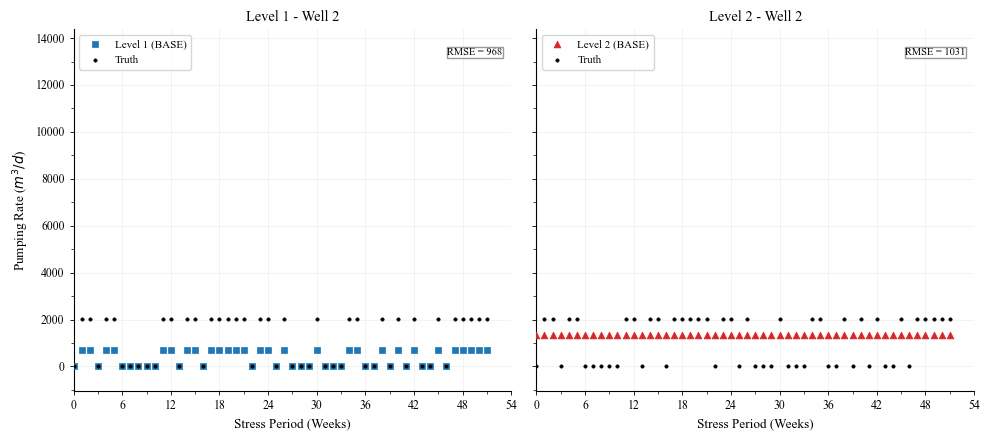

[OK] Saved well 2 comparison to: c:\python\Personal\kfm-ms\codes\figures\truth_well12_level1_vs_level2_all_realizations.svg


In [49]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ==============================================================================
# STYLE
# ==============================================================================
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ==============================================================================
# PATHS
# ==============================================================================
BASE_DIR = Path(r"c:\python\Personal\kfm-ms\codes")

LEVEL1_DIR = BASE_DIR / "pest_level_1"
LEVEL2_DIR = BASE_DIR / "pest_level_2"

MASTER_RUN_L1_DIR = BASE_DIR / "master_run_level_1"
MASTER_RUN_L2_DIR = BASE_DIR / "master_run_level_2"

TRUTH_PATH = MASTER_RUN_L1_DIR / "master_truth.csv"

FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_FIG_WELL0 = FIG_DIR / "truth_well12_level1_vs_level2_all_realizations.svg"
OUT_RMSE_CSV = FIG_DIR / "truth_schedule_rmse_summary.csv"

TOKEN_REGEX = re.compile(r"_r:(\d+)_c:(\d+)_sp:(\d+)")

WELL_ID_TO_PLOT = 2

# ==============================================================================
# HELPERS
# ==============================================================================
def find_latest_par_file(run_dir: Path, master_run_dir: Path) -> Path:
    par_files = sorted(run_dir.glob("*inversion_level_*.par.csv"))
    if not par_files:
        par_files = sorted(master_run_dir.glob("*inversion_level_*.par.csv"))
    if not par_files:
        raise FileNotFoundError(
            f"No parameter CSV files found in {run_dir} or {master_run_dir}"
        )
    return par_files[-1]


def load_grid_template(run_dir: Path) -> pd.DataFrame:
    grid_path = run_dir / "org" / "grid_candidates.csv"
    if not grid_path.exists():
        grid_path = run_dir / "grid_candidates.csv"
    if not grid_path.exists():
        raise FileNotFoundError(f"Missing grid file in {run_dir}")
    return pd.read_csv(grid_path)


def load_realizations_and_base(par_file: Path) -> tuple[pd.DataFrame, pd.Series]:
    df_pars = pd.read_csv(par_file, index_col=0)
    realizations_df = df_pars.drop(index="base", errors="ignore")

    base_file_name = par_file.name.replace(".par.csv", ".base.par")

    possible_paths = [
        par_file.parent / base_file_name,
        par_file.parent / "master_run" / base_file_name,
        MASTER_RUN_L1_DIR / base_file_name,
        MASTER_RUN_L1_DIR / "master_run" / base_file_name,
        MASTER_RUN_L2_DIR / base_file_name,
        MASTER_RUN_L2_DIR / "master_run" / base_file_name,
    ]

    base_file_path = None
    for path in possible_paths:
        if path.exists():
            base_file_path = path
            break

    if base_file_path is not None:
        df_base_raw = pd.read_csv(
            base_file_path,
            sep=r"\s+",
            skiprows=1,
            names=["parnme", "parval", "scale", "offset"]
        )
        base_series = df_base_raw.set_index("parnme")["parval"]
        print(f"[INFO] Successfully loaded base run from: {base_file_path}")
    else:
        print(f"[WARNING] Could not find '{base_file_name}' in any standard directories.")
        print(f"          Checked: {[str(p) for p in possible_paths]}")
        print("          Defaulting to first ensemble row.")
        base_series = df_pars.iloc[0]
        realizations_df = df_pars.iloc[1:]

    return realizations_df, base_series


def make_truth_schedule(truth_df: pd.DataFrame) -> pd.DataFrame:
    required = {"well_id", "r", "c", "sp", "q"}
    missing = required - set(truth_df.columns)
    if missing:
        raise KeyError(f"Truth file missing columns: {missing}")
    return truth_df[["well_id", "r", "c", "sp", "q"]].copy().sort_values(
        ["well_id", "sp", "r", "c"]
    ).reset_index(drop=True)


def make_effective_schedule_multi(
    par_data: pd.DataFrame | pd.Series,
    grid_template: pd.DataFrame,
    truth_df: pd.DataFrame
) -> pd.DataFrame:
    well_map = (
        truth_df[["r", "c", "well_id"]]
        .drop_duplicates()
        .set_index(["r", "c"])["well_id"]
        .to_dict()
    )

    qref_lookup = {
        (int(r), int(c), int(sp)): float(qref)
        for r, c, sp, qref in grid_template[["r", "c", "sp", "qref"]].itertuples(index=False, name=None)
    }

    if isinstance(par_data, pd.Series):
        df_m = pd.DataFrame([par_data])
    else:
        df_m = par_data

    records = []
    for col_name in df_m.columns:
        m = TOKEN_REGEX.search(str(col_name))
        if not m:
            continue

        r = int(m.group(1))
        c = int(m.group(2))
        sp = int(m.group(3))

        qref = qref_lookup.get((r, c, sp), None)
        if qref is None:
            continue

        well_id = well_map.get((r, c), -1)
        multipliers = df_m[col_name].values

        for idx, mult in enumerate(multipliers):
            realization_id = "base" if isinstance(par_data, pd.Series) else df_m.index[idx]
            records.append({
                "realization": realization_id,
                "well_id": well_id,
                "r": r,
                "c": c,
                "sp": sp,
                "q_effective": float(qref) * float(mult),
            })

    out = pd.DataFrame(records)
    if out.empty:
        raise ValueError("No parsable pumping values found.")
    return out.sort_values(["realization", "well_id", "sp", "r", "c"]).reset_index(drop=True)


def compute_rmse_metrics(base_sched: pd.DataFrame, truth_sched: pd.DataFrame) -> dict:
    merged = truth_sched[["well_id", "sp", "q"]].merge(
        base_sched[["well_id", "sp", "q_effective"]],
        on=["well_id", "sp"],
        how="inner"
    )

    if merged.empty:
        raise ValueError("No overlapping truth/base schedule entries found for RMSE calculation.")

    diff = merged["q_effective"] - merged["q"]
    rmse = float(np.sqrt(np.mean(diff**2)))

    truth_mean = float(merged["q"].mean())
    nrmse = rmse / truth_mean if truth_mean != 0 else np.nan

    return {
        "rmse": rmse,
        "truth_mean": truth_mean,
        "nrmse": nrmse,
        "n_points": int(len(merged)),
    }


def compute_well_rmse(base_sched: pd.DataFrame, truth_sched: pd.DataFrame, well_id: int) -> float:
    merged = truth_sched[truth_sched["well_id"] == well_id][["well_id", "sp", "q"]].merge(
        base_sched[base_sched["well_id"] == well_id][["well_id", "sp", "q_effective"]],
        on=["well_id", "sp"],
        how="inner"
    )

    if merged.empty:
        raise ValueError(f"No overlapping truth/base entries found for well {well_id}.")

    diff = merged["q_effective"] - merged["q"]
    return float(np.sqrt(np.mean(diff ** 2)))


def calculate_global_y_limits(truth_sched, l1_real_sched_all, l2_real_sched_all, well_id: int):
    all_vals = []

    t_w = truth_sched[truth_sched["well_id"] == well_id]
    if not t_w.empty:
        all_vals.extend(t_w["q"].tolist())

    for sched in [l1_real_sched_all, l2_real_sched_all]:
        w = sched[sched["well_id"] == well_id]
        if not w.empty:
            all_vals.extend(w["q_effective"].tolist())

    if not all_vals:
        return None

    ymin = min(all_vals)
    ymax = max(all_vals)
    pad = (ymax - ymin) * 0.08 if ymax != ymin else 1.0
    return ymin - pad, ymax + pad


def plot_like_full_axes(ax, y_limits):
    ax.set_xlim(0, 54)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(3))
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))

    if y_limits is not None:
        ax.set_ylim(y_limits)

    ax.tick_params(axis="both", direction="out", length=3, width=0.6)
    ax.tick_params(axis="x", which="minor", length=2, width=0.5)
    ax.tick_params(axis="y", which="minor", length=2, width=0.5)


def plot_well_side_by_side(truth_sched, l1_real_sched_all, l2_real_sched_all, l1_base_sched, l2_base_sched, y_limits, out_path):
    well_id = WELL_ID_TO_PLOT

    t_w = truth_sched[truth_sched["well_id"] == well_id].sort_values("sp")
    l1_b = l1_base_sched[l1_base_sched["well_id"] == well_id].sort_values("sp")
    l2_b = l2_base_sched[l2_base_sched["well_id"] == well_id].sort_values("sp")

    if t_w.empty:
        raise ValueError(f"No truth data found for well {well_id}.")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

    panels = [
        ("Level 1", axes[0], l1_b, l1_base_sched, "#1f77b4", "s", l1_base_sched),
        ("Level 2", axes[1], l2_b, l2_base_sched, "#d62728", "^", l2_base_sched),
    ]

    for label, ax, base_w, base_sched, color, marker, _ in panels:
        if base_w.empty:
            ax.set_axis_off()
            continue

        # BASE only
        ax.scatter(
            base_w["sp"],
            base_w["q_effective"],
            color=color,
            s=24,
            marker=marker,
            edgecolors=color,
            linewidths=0.5,
            label=f"{label} (BASE)",
            zorder=4
        )

        # Truth
        ax.scatter(
            t_w["sp"],
            t_w["q"],
            color="black",
            s=6,
            marker="o",
            edgecolors="black",
            linewidths=0.4,
            label="Truth",
            zorder=5
        )

        # RMSE label for this well only
        well_rmse = compute_well_rmse(
            l1_base_sched if label == "Level 1" else l2_base_sched,
            truth_sched,
            well_id
        )
        ax.text(
            0.98, 0.95,
            f"RMSE = {int(round(well_rmse))}",
            transform=ax.transAxes,
            va="top",
            ha="right",
            fontsize=7.5,
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.80, pad=0.2)
        )

        plot_like_full_axes(ax, y_limits)

        ax.set_title(f"{label} - Well {well_id}")
        ax.set_xlabel("Stress Period (Weeks)")
        ax.grid(True, alpha=0.2, linewidth=0.5)

    axes[0].set_ylabel("Pumping Rate ($m^3/d$)")
    axes[0].legend(loc="best", fontsize=8)
    axes[1].legend(loc="upper left", fontsize=8)

    fig.tight_layout()
    fig.savefig(out_path)
    plt.show()

    print(f"[OK] Saved well {well_id} comparison to: {out_path}")


# ==============================================================================
# MAIN
# ==============================================================================
def main():
    print(f"[INFO] Reading truth from: {TRUTH_PATH}")
    truth_df = pd.read_csv(TRUTH_PATH)

    par_file_l1 = find_latest_par_file(LEVEL1_DIR, MASTER_RUN_L1_DIR)
    par_file_l2 = find_latest_par_file(LEVEL2_DIR, MASTER_RUN_L2_DIR)

    grid_l1 = load_grid_template(LEVEL1_DIR)
    grid_l2 = load_grid_template(LEVEL2_DIR)

    _, l1_base_ser = load_realizations_and_base(par_file_l1)
    _, l2_base_ser = load_realizations_and_base(par_file_l2)

    truth_sched = make_truth_schedule(truth_df)

    l1_base_sched = make_effective_schedule_multi(l1_base_ser, grid_l1, truth_df)
    l2_base_sched = make_effective_schedule_multi(l2_base_ser, grid_l2, truth_df)

    # Build full-realization schedules ONLY to set matching axes limits
    l1_real_df_all, _ = load_realizations_and_base(par_file_l1)
    l2_real_df_all, _ = load_realizations_and_base(par_file_l2)
    l1_real_sched_all = make_effective_schedule_multi(l1_real_df_all, grid_l1, truth_df)
    l2_real_sched_all = make_effective_schedule_multi(l2_real_df_all, grid_l2, truth_df)

    y_limits = calculate_global_y_limits(
        truth_sched,
        l1_real_sched_all,
        l2_real_sched_all,
        WELL_ID_TO_PLOT
    )

    plot_well_side_by_side(
        truth_sched=truth_sched,
        l1_real_sched_all=l1_real_sched_all,
        l2_real_sched_all=l2_real_sched_all,
        l1_base_sched=l1_base_sched,
        l2_base_sched=l2_base_sched,
        y_limits=y_limits,
        out_path=OUT_FIG_WELL0
    )


if __name__ == "__main__":
    main()